In [36]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [37]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=64,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=64,
                                          shuffle=False)

In [38]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.rnn(x, h0)

        out = self.fc(out[:, -1, :])
        return out

In [39]:
input_size = 28
hidden_size = 128
num_layers = 1
num_classes = 10

model = RNN(input_size, hidden_size, num_layers, num_classes).to(device)

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [41]:
grad_list = []

num_epochs = 3

for epoch in range(num_epochs):
    for images, labels in train_loader:

        images = images.squeeze(1).permute(0, 2, 1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()

        # store gradient
        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_list.append(param.grad.abs().mean().item())
                break

        optimizer.step()

In [42]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.squeeze(1).permute(0, 2, 1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 93.12%


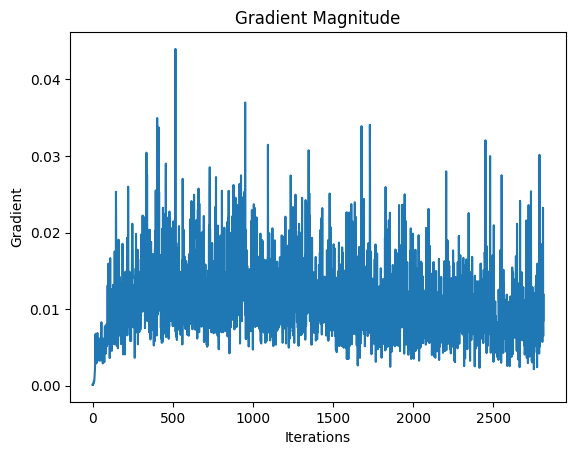

In [43]:
plt.plot(grad_list)
plt.title("Gradient Magnitude")
plt.xlabel("Iterations")
plt.ylabel("Gradient")
plt.show()